# Phase 1 — Exploratory Data Analysis
## Ambrish Loganathan
## 23BDS0074

Tasks:
1. Loading the dataset
2. Basic statistical analysis
3. Handling missing data
4. Data cleaning
5. Data transformation
6. Univariate analysis (3+ visualizations)
7. Bivariate analysis (3+ visualizations)
8. Multivariate analysis (3+ visualizations)


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)


## 1. Loading the Dataset

In [59]:
df = pd.read_csv("https://raw.githubusercontent.com/salemprakash/EDA/refs/heads/main/Data/diabetes.csv")
print("Shape:", df.shape)
df.head()


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148,72,35,0,33.6,0.627,50,1
1,1.0,85,66,29,0,26.6,0.351,31,0
2,8.0,183,64,0,0,23.3,0.672,32,1
3,1.0,89,66,23,94,28.1,0.167,21,0
4,0.0,137,40,35,168,43.1,2.288,33,1


In [60]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               767 non-null    float64
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  767 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 54.1+ KB


## 2. Basic Statistical Analysis

In [61]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,767.000000,768.000000,768.000000,768.000000,768.000000,768.000000,767.000000,768.000000
mean,3.850065,120.894531,69.105469,20.536458,79.799479,31.992578,0.471995,33.240885
std,3.368910,31.972618,19.355807,15.952218,115.244002,7.884160,0.331529,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243500,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.371000,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626500,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [62]:
df.groupby("Outcome").mean(numeric_only=True)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.313883,109.977912,68.172691,19.686747,69.068273,30.299799,0.429885,31.208835
1,4.857678,141.411985,71.089888,22.247191,100.711610,35.161798,0.550749,37.086142
?,3.000000,107.000000,47.333333,9.333333,0.000000,30.933333,0.439000,28.333333


In [63]:
print("Skewness:\n", df.skew(numeric_only=True))
print("\nKurtosis:\n", df.kurt(numeric_only=True))


Skewness:
 Pregnancies                 0.900862
Glucose                     0.173754
BloodPressure              -1.843608
SkinThickness               0.109372
Insulin                     2.272251
BMI                        -0.428982
DiabetesPedigreeFunction    1.917900
Age                         1.129597
dtype: float64

Kurtosis:
 Pregnancies                 0.158261
Glucose                     0.640780
BloodPressure               5.180157
SkinThickness              -0.520072
Insulin                     7.214260
BMI                         3.290443
DiabetesPedigreeFunction    5.582729
Age                         0.643159
dtype: float64


## 3. Handling Missing Data

In this dataset, biologically impossible zero values in certain columns
(`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) actually
represent missing data rather than true zeros. We first convert these to `NaN`
so they can be handled properly.

In [64]:
df.isnull().sum()


,0
Pregnancies,1
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,1
Age,0
Outcome,0


In [65]:
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df_clean = df.copy()
df_clean[zero_as_missing_cols] = df_clean[zero_as_missing_cols].replace(0, np.nan)

print("Missing values after converting zeros to NaN:")
df_clean.isnull().sum()


Missing values after converting zeros to NaN:


,0
Pregnancies,1
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,1
Age,0
Outcome,0


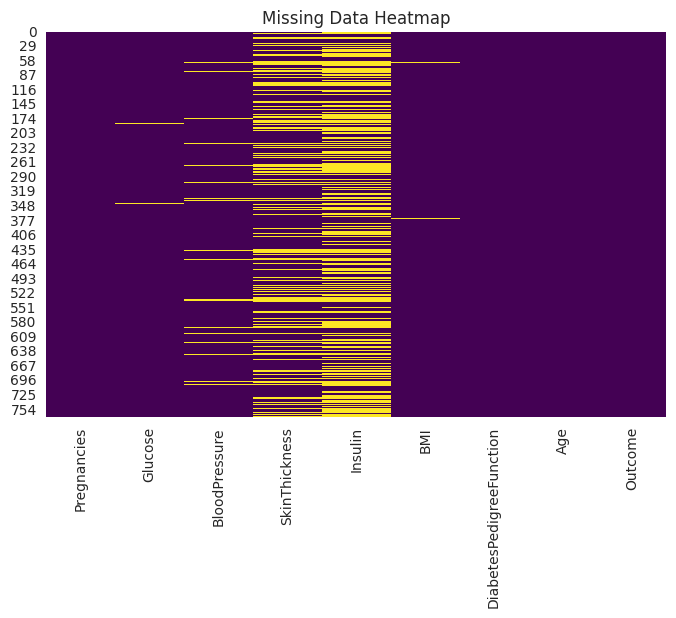

In [66]:
plt.figure(figsize=(8, 5))
sns.heatmap(df_clean.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()


In [67]:
for col in zero_as_missing_cols:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Missing values after imputation:")
df_clean.isnull().sum()


Missing values after imputation:


,0
Pregnancies,1
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,3
BMI,0
DiabetesPedigreeFunction,1
Age,0
Outcome,0


## 4. Data Cleaning

In [68]:
print("Duplicate rows:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()


print("\nData types:\n", df_clean.dtypes)


Duplicate rows: 0

Data types:
 Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                      object
dtype: object


In [69]:
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

numeric_cols = df_clean.select_dtypes(include=np.number).columns
outlier_counts = {col: count_outliers_iqr(df_clean[col]) for col in numeric_cols}
outlier_counts


{'Pregnancies': np.int64(4),
 'Glucose': np.int64(0),
 'BloodPressure': np.int64(14),
 'SkinThickness': np.int64(87),
 'Insulin': np.int64(51),
 'BMI': np.int64(8),
 'DiabetesPedigreeFunction': np.int64(29),
 'Age': np.int64(9)}

In [70]:
df_capped = df_clean.copy()
for col in numeric_cols:
    if col == "Outcome":
        continue
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

df_capped.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,767.000000,768.000000,768.000000,768.000000,765.000000,768.000000,767.000000,768.000000
mean,3.842243,121.677083,72.356120,28.844401,133.118301,32.372786,0.459053,33.199870
std,3.343462,30.464161,11.706669,7.558132,58.202245,6.672767,0.285867,11.628404
min,0.000000,44.000000,40.000000,14.500000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243500,24.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.371000,29.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626500,41.000000
max,13.500000,199.000000,104.000000,42.500000,270.000000,50.250000,1.201000,66.500000


## 5. Data Transformation

We create a scaled version of the features (useful for downstream modeling)
and bin `Age` and `BMI` into meaningful categories.

In [71]:
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in df_capped.columns if c != "Outcome"]
scaler = StandardScaler()

df_scaled = df_capped.copy()
df_scaled[feature_cols] = scaler.fit_transform(df_capped[feature_cols])
df_scaled.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.645787,0.864625,-0.030440,0.814965,0.625500,0.184034,0.587882,1.445691,1
1,-0.850644,-1.204727,-0.543302,0.020600,-0.526412,-0.865690,-0.378232,-0.189304,0
2,1.244360,2.014265,-0.714257,0.417782,0.625500,-1.360560,0.745401,-0.103252,1
3,-0.850644,-1.073339,-0.543302,-0.773764,-0.672550,-0.640749,-1.022308,-1.049828,0
4,-1.149931,0.503310,-2.765706,0.814965,0.599711,1.608659,2.597119,-0.017199,1


In [72]:
df_capped["AgeGroup"] = pd.cut(
    df_capped["Age"], bins=[20, 30, 40, 50, 60, 100],
    labels=["21-30", "31-40", "41-50", "51-60", "60+"]
)

df_capped["BMICategory"] = pd.cut(
    df_capped["BMI"], bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

df_capped[["Age", "AgeGroup", "BMI", "BMICategory"]].head()


,Age,AgeGroup,BMI,BMICategory
0,50.0,41-50,33.6,Obese
1,31.0,31-40,26.6,Overweight
2,32.0,31-40,23.3,Normal
3,21.0,21-30,28.1,Overweight
4,33.0,31-40,43.1,Obese


## 6. Univariate Analysis (3+ Visualizations)

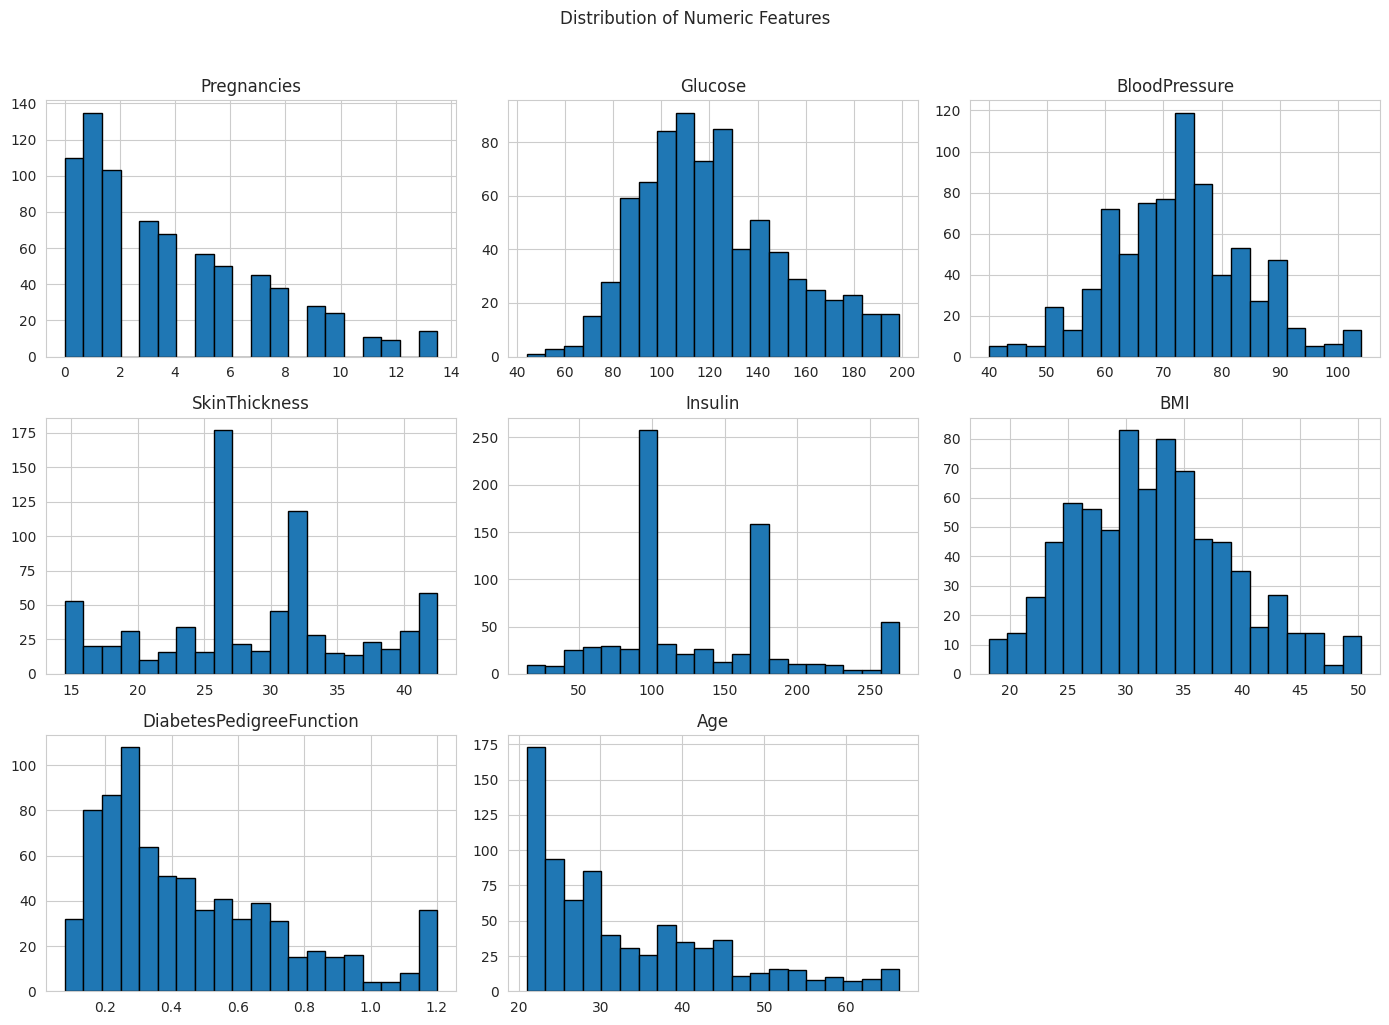

In [73]:
df_capped[numeric_cols].hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Distribution of Numeric Features", y=1.02)
plt.tight_layout()
plt.show()


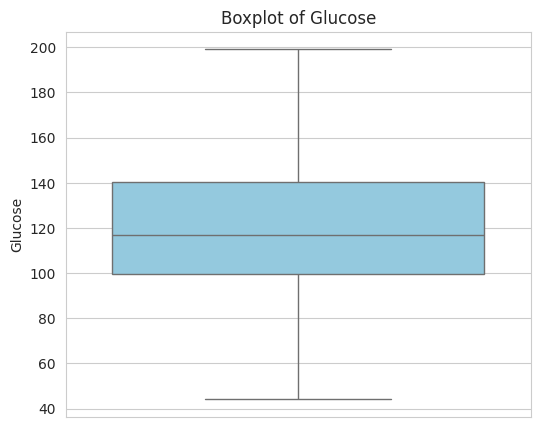

In [74]:
plt.figure(figsize=(6, 5))
sns.boxplot(y=df_capped["Glucose"], color="skyblue")
plt.title("Boxplot of Glucose")
plt.show()


/tmp/ipykernel_5250/805478995.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=df_capped, palette="Set2")


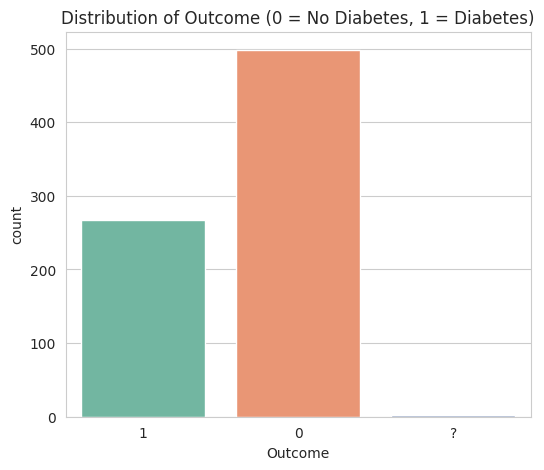

In [75]:
plt.figure(figsize=(6, 5))
sns.countplot(x="Outcome", data=df_capped, palette="Set2")
plt.title("Distribution of Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.show()


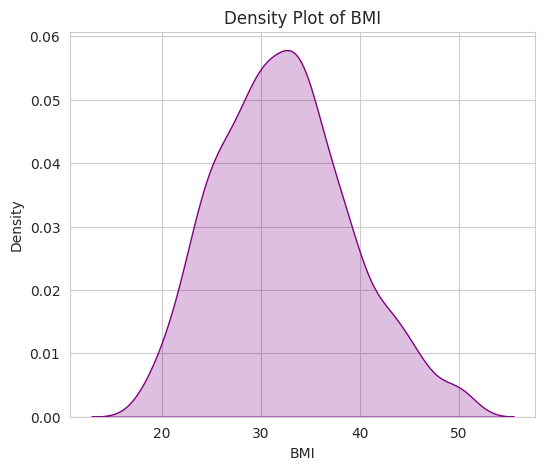

In [76]:
plt.figure(figsize=(6, 5))
sns.kdeplot(df_capped["BMI"], fill=True, color="purple")
plt.title("Density Plot of BMI")
plt.show()


## 7. Bivariate Analysis (3+ Visualizations)

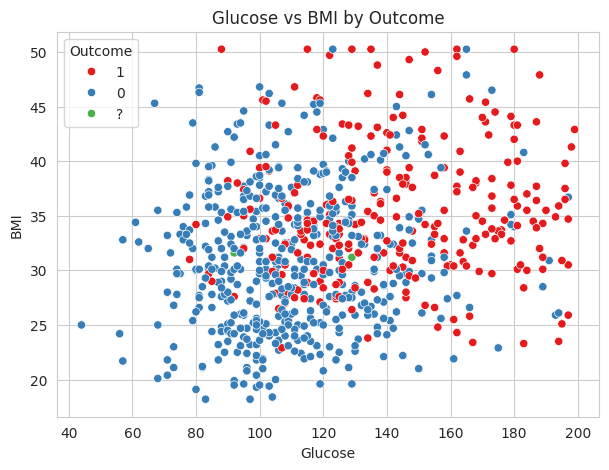

In [77]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="Glucose", y="BMI", hue="Outcome", data=df_capped, palette="Set1")
plt.title("Glucose vs BMI by Outcome")
plt.show()


/tmp/ipykernel_5250/3872956204.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y="Age", data=df_capped, palette="Set3")


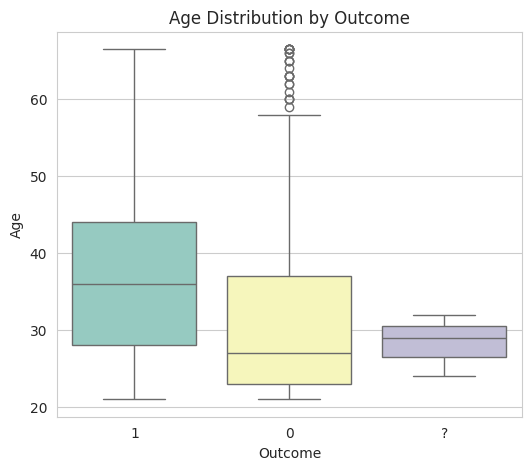

In [78]:
plt.figure(figsize=(6, 5))
sns.boxplot(x="Outcome", y="Age", data=df_capped, palette="Set3")
plt.title("Age Distribution by Outcome")
plt.show()


/tmp/ipykernel_5250/2268327151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AgeGroup", y="Glucose", data=df_capped, palette="viridis")


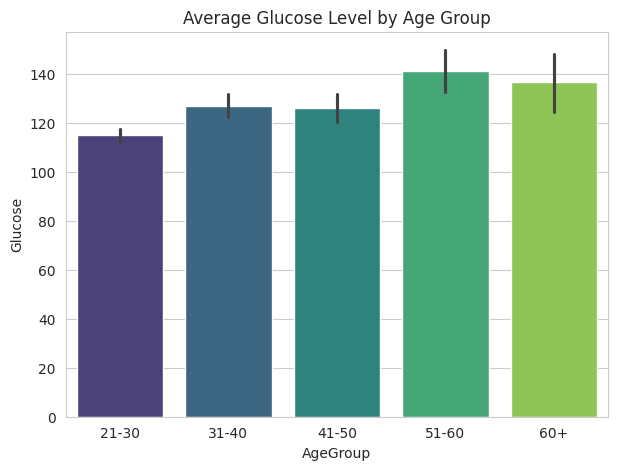

In [79]:
plt.figure(figsize=(7, 5))
sns.barplot(x="AgeGroup", y="Glucose", data=df_capped, palette="viridis")
plt.title("Average Glucose Level by Age Group")
plt.show()


/tmp/ipykernel_5250/318778008.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Outcome", y="Insulin", data=df_capped, palette="muted")


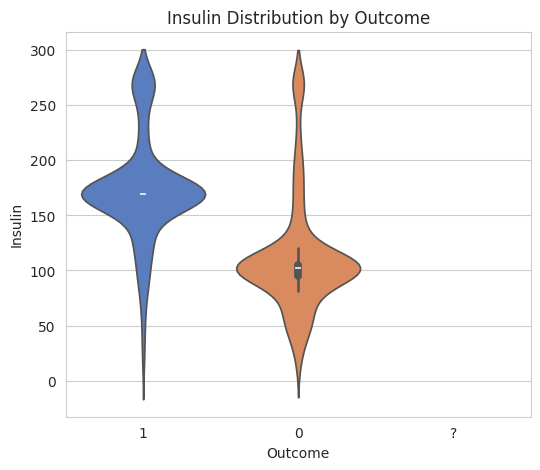

In [80]:
plt.figure(figsize=(6, 5))
sns.violinplot(x="Outcome", y="Insulin", data=df_capped, palette="muted")
plt.title("Insulin Distribution by Outcome")
plt.show()


## 8. Multivariate Analysis (3+ Visualizations)

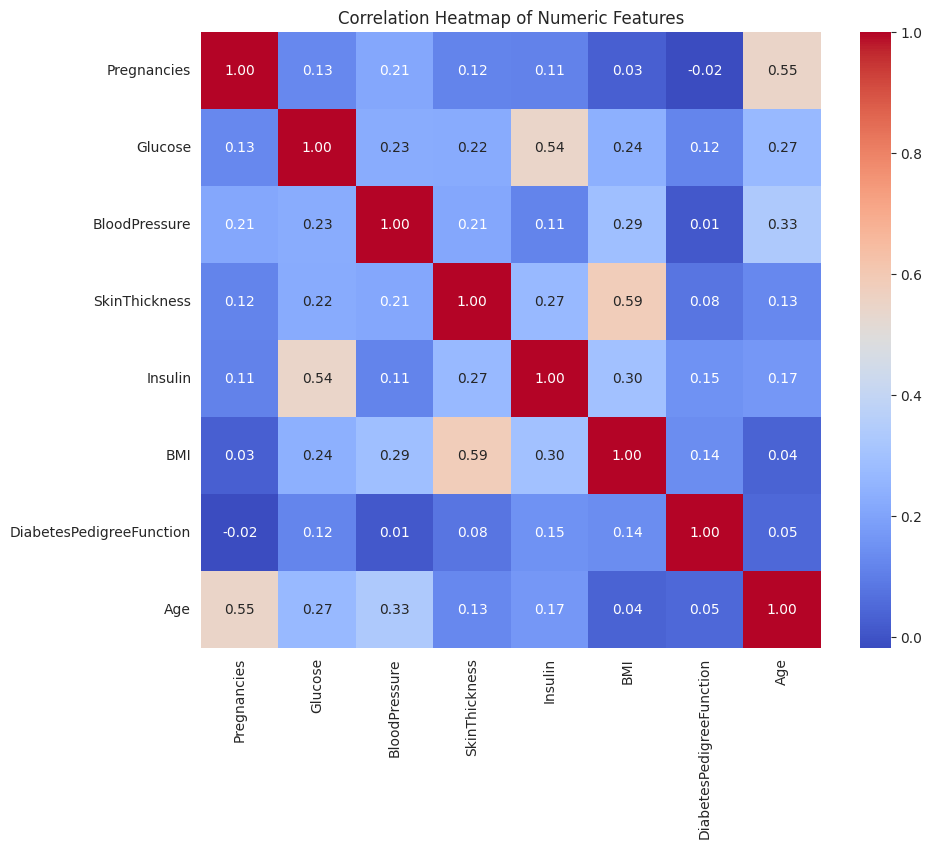

In [81]:
plt.figure(figsize=(10, 8))
corr = df_capped[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


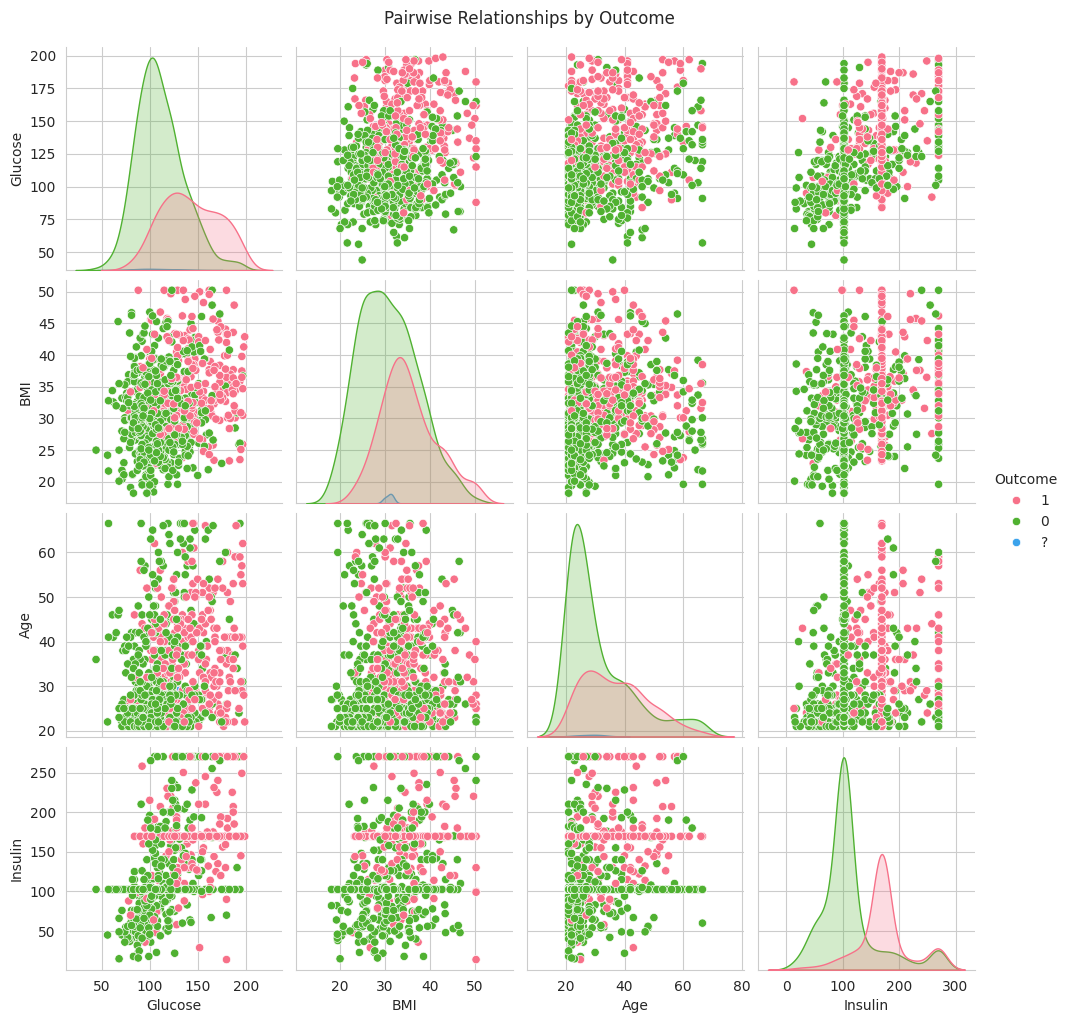

In [82]:
sns.pairplot(
    df_capped,
    vars=["Glucose", "BMI", "Age", "Insulin"],
    hue="Outcome",
    palette="husl",
    diag_kind="kde"
)
plt.suptitle("Pairwise Relationships by Outcome", y=1.02)
plt.show()


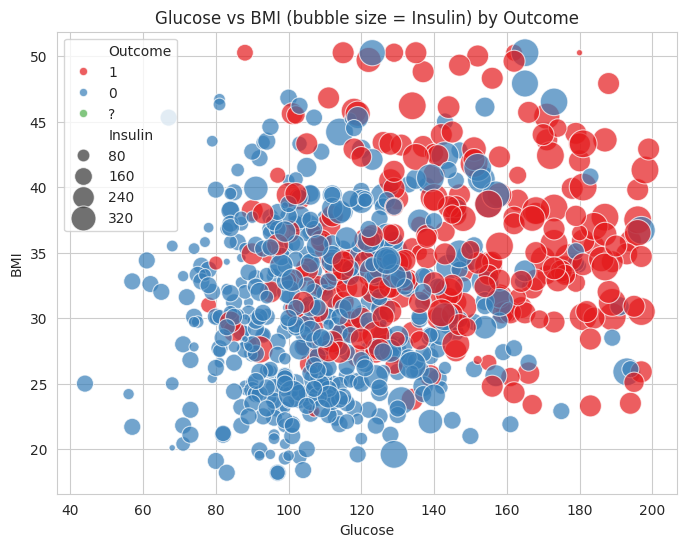

In [83]:
plt.figure(figsize=(8, 6))
sizes = (df_capped["Insulin"] - df_capped["Insulin"].min() + 10) * 1.5
sns.scatterplot(
    x="Glucose", y="BMI", size=sizes, hue="Outcome",
    data=df_capped, sizes=(20, 400), palette="Set1", alpha=0.7, legend="brief"
)
plt.title("Glucose vs BMI (bubble size = Insulin) by Outcome")
plt.show()


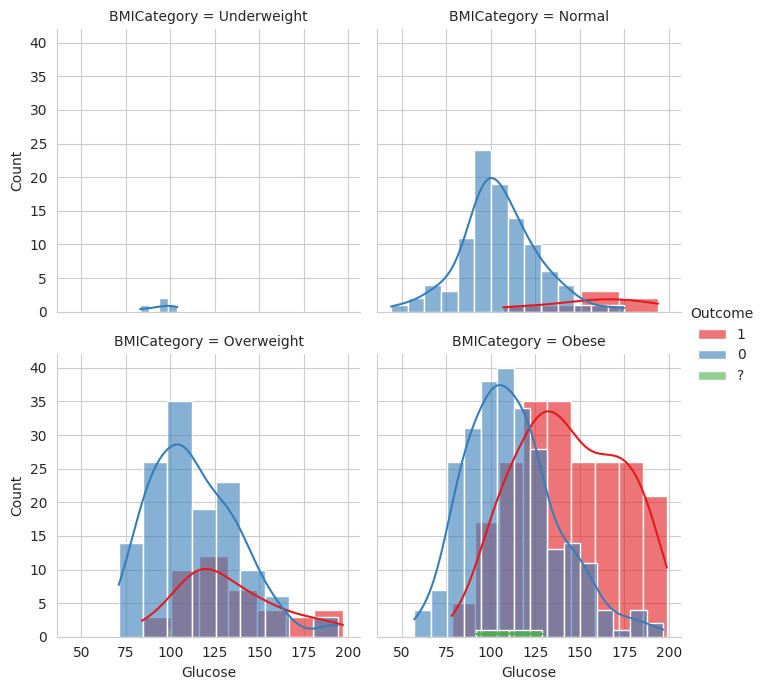

In [84]:
g = sns.FacetGrid(df_capped, col="BMICategory", hue="Outcome", palette="Set1", col_wrap=2, height=3.5)
g.map(sns.histplot, "Glucose", kde=True, alpha=0.6)
g.add_legend()
plt.show()
